**Step 1: Data Preprocessing**

Importing the libraries

In [62]:
import pandas as pd
import numpy as np

Importing the dataset

In [63]:
dataset = pd.read_csv('../../datasets/day-08-50_Startups.csv')

In [64]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [65]:
X = dataset.iloc[ : , :-1].values
Y = dataset.iloc[ : ,  -1].values

Encoding Categorical data

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(drop='first'), [3])
    ],
    remainder="passthrough"
)

X = np.array(ct.fit_transform(X))

***Avoiding Dummy Variable Trap***: in the above block of code i have used drop = 'first' - This automatically avoids the dummy variable trap

Splitting the dataset into the Training set and Test set

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

**Step 2: Fitting Multiple Linear Regression to the Training set**

In [68]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Step 3: Predicting the Test set results**

In [69]:
y_pred = regressor.predict(X_test)

**Step 4: Evaluation of Results**

In [70]:
from sklearn.metrics import r2_score

score = r2_score(Y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.8987266414319832


y = b0 + b1x1 + b2x2 + ... bnxn

In [71]:
print("Coefficients (b1..bn):", regressor.coef_)
print("Intercept (b0):", regressor.intercept_)

Coefficients (b1..bn): [ 9.38793006e+02  6.98775997e+00  8.05630064e-01 -6.87878823e-02
  2.98554429e-02]
Intercept (b0): 54028.03959405866


In [72]:
comparison = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": y_pred
})

print(comparison)

      Actual      Predicted
0  134307.35  126362.879083
1   81005.76   84608.453836
2   99937.59   99677.494252
3   64926.08   46357.460686
4  125370.37  128750.482885
5   35673.41   50912.417419
6  105733.54  109741.350327
7  107404.34  100643.242816
8   97427.84   97599.275746
9  122776.86  113097.425244


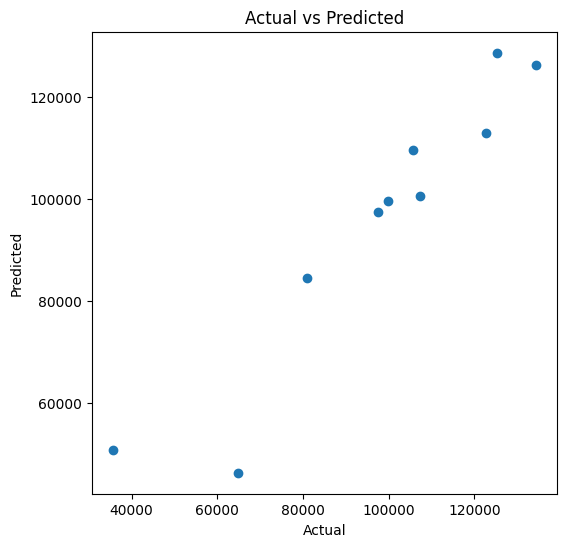

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(Y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()